Contents:


# Exploratory Data Analysis: EIA Metadata

## Introduction

This notebook analyzes the U.S. Energy Information Administration (EIA) electricity metadata retrieved from the v2 API. The goal is to understand how time series are structured across datasets, frequencies, and facet dimensions to support downstream data exploration and analysis.

## Imports

In [1]:
%load_ext autoreload
%autoreload 2
import logging
import os
import io
import ast
from typing import Tuple, Dict

import helpers.hdbg as hdbg
import helpers.henv as henv
import helpers.hprint as hprint
import helpers.hs3 as hs3
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import causal_automl.eda_utils as caueduti

In [2]:
# Configure logger.
hdbg.init_logger(verbosity=logging.INFO)
_LOG = logging.getLogger(__name__)

# Configure the notebook style.
hprint.config_notebook()

# Configure S3.
s3_dir = "s3://causify-data-collaborators/causal_automl/metadata/"
aws_profile = "ck"

INFO  > cmd='/venv/lib/python3.12/site-packages/ipykernel_launcher.py -f /home/.local/share/jupyter/runtime/kernel-441511ff-091e-46a8-a388-c9e01b49cb6b.json'


## Helper Functions

In [94]:
def _get_missing_summary(df: pd.DataFrame) -> pd.DataFrame:
    """
    Returns a summary of missing value count and percentage per column.

    :param df: data to inspect
    :return: data with count and percentage of missing values
    """
    count = df.isna().sum()
    percent = df.isna().mean() * 100
    missing_count = pd.DataFrame({'Missing Count': count, 'Missing %': percent}).sort_values(by="Missing %", ascending=False)
    missing_columns_df = missing_count[
        missing_count["Missing Count"] > 0
    ]
    return missing_columns_df

def _plot_distribution(df_metadata: pd.DataFrame, column: str, title: str) -> None:
    """
    Plot a distribution count for a specified metadata column.

    :param df_metadata: metadata table containing time series fields
    :param column: column to group and count values by (e.g.,
        'frequency_id', 'data_units')
    :param title: title for the plot
    """
    if column not in df_metadata.columns:
        raise ValueError(f"Column '{column}' not found in df_metadata.")
    counts = df_metadata[column].value_counts()
    caueduti.plot_top_n_annotated_bar(
        counts=counts,
        total=len(df_metadata),
        top_n=len(counts),
        title=title,
        xlabel=column.replace("_", " ").title(),
        ylabel="Count",
        wrap_width=35,
        rotation=30,
    )

## Load and Preprocess Data

In [4]:
def _load_data(file_path: str, aws_profile:str) -> pd.DataFrame:
    """
    Load data from file path to a DataFrame.

    :param file_path: path of the data to load from
    :param aws_profile: AWS CLI profile used for access
    :return: DataFrame of the loaded data
    """
    file = hs3.from_file(file_path, aws_profile=aws_profile)
    df = pd.read_csv(io.StringIO(file))
    return df

def _load_eia_metadata_and_parameters(
    s3_dir: str,
    metadata_file_path: str,
    parameter_subdir: str,
    aws_profile: str,
) -> Tuple[pd.DataFrame, Dict[str, pd.DataFrame]]:
    """
    Load EIA metadata and parameter files from S3.

    :param s3_dir: base S3 directory (e.g., "s3://mybucket/data/")
    :param metadata_file: metadata CSV filename (e.g., "eia_metadata.csv")
    :param parameter_subdir: subdirectory in `s3_dir` containing parameter files
    :param aws_profile: AWS CLI profile used for access
    :return: metadata and parameter DataFrames
    """
    # Load metadata CSV.
    metadata_path = os.path.join(s3_dir, metadata_file_path)
    df_metadata = _load_data(metadata_path, aws_profile)
    # Load all parameter CSVs.
    parameter_dir = os.path.join(s3_dir, parameter_subdir)
    s3fs_ = hs3.get_s3fs("ck")
    param_paths = s3fs_.ls(parameter_dir)
    param_dfs = {}
    for path in param_paths:
        if path.endswith(".csv"):
            key = os.path.basename(path).replace("_parameters.csv", "")
            full_path = f"s3://{path}"
            param_dfs[key] = _load_data(full_path, aws_profile)
    return df_metadata, param_dfs

def _preprocess_eia(
    df_metadata: pd.DataFrame,
    param_dfs: Dict[str, pd.DataFrame],
) -> Tuple[pd.DataFrame, Dict[str, pd.DataFrame]]:
    """
    Preprocess metadata and parameter DataFrames for analysis.

    :param df_metadata: metadata index DataFrame
    :param param_dfs: parameter DataFrames
    :return: cleaned metadata and parameter DataFrames
    """
    # Preprocess metadata.
    df_metadata["frequency_id"] = df_metadata["frequency_id"].str.lower().str.strip()
    # Parse facets column if stored as string.
    df_metadata["facets"] = df_metadata["facets"].apply(ast.literal_eval)
    # Preprocess parameters.
    param_dfs_cleaned = {}
    for file_name, df_param in param_dfs.items():
        df_param_cleaned = df_param.copy()
        df_param_cleaned["facet_id"] = (
            df_param_cleaned["facet_id"].astype(str).str.strip().str.lower()
        )
        # Strip and clean id field in known affected file.
        df_param_cleaned["id"] = df_param_cleaned["id"].astype(str).str.strip()
        param_dfs_cleaned[file_name] = df_param_cleaned
    return df_metadata, param_dfs_cleaned

In [52]:
# Load EIA metadata index and parameters.
metadata_s3_path = f"eia_electricity_metadata_original_v1.0.csv"
param_s3_dir = f"eia_parameters_v1.0"
df_metadata, param_dfs = _load_eia_metadata_and_parameters(s3_dir, metadata_s3_path, param_s3_dir, aws_profile)
# Preprocess EIA metadata index and parameters.
df_metadata, param_dfs = _preprocess_eia(df_metadata, param_dfs)

## Introductory Analytics

### Preview Data

In [25]:
# Preview metadata.
print(f"Number of time series: {len(df_metadata)}")
print(f"Number of columns: {df_metadata.shape[1]}")
print(f"Number of unique datasets: {df_metadata['dataset_id'].nunique()}")
df_metadata.head()

Number of time series: 172
Number of columns: 17
Number of unique datasets: 19


,url,id,dataset_id,name,description,frequency_id,frequency_alias,frequency_description,frequency_query,frequency_format,facets,data,data_alias,data_units,start_period,end_period,parameter_values_file
0,https://api.eia.gov/v2/electricity/retail-sale...,retail_sales_monthly_revenue,retail_sales,Electricity Sales to Ultimate Customers,Electricity sales to ultimate customer by stat...,monthly,NaN,One data point for each month.,M,YYYY-MM,"[{'id': 'stateid', 'description': 'State / Cen...",revenue,Revenue from Sales to Ultimate Customers,million dollars,2001-01,2025-02,eia_parameters_v1.0/retail_sales_parameters.csv
1,https://api.eia.gov/v2/electricity/retail-sale...,retail_sales_monthly_sales,retail_sales,Electricity Sales to Ultimate Customers,Electricity sales to ultimate customer by stat...,monthly,NaN,One data point for each month.,M,YYYY-MM,"[{'id': 'stateid', 'description': 'State / Cen...",sales,Megawatt-hours Sold to Ultimate Customers,million kilowatt hours,2001-01,2025-02,eia_parameters_v1.0/retail_sales_parameters.csv
2,https://api.eia.gov/v2/electricity/retail-sale...,retail_sales_monthly_price,retail_sales,Electricity Sales to Ultimate Customers,Electricity sales to ultimate customer by stat...,monthly,NaN,One data point for each month.,M,YYYY-MM,"[{'id': 'stateid', 'description': 'State / Cen...",price,Average Price of Electricity to Ultimate Custo...,cents per kilowatt-hour,2001-01,2025-02,eia_parameters_v1.0/retail_sales_parameters.csv
3,https://api.eia.gov/v2/electricity/retail-sale...,retail_sales_monthly_customers,retail_sales,Electricity Sales to Ultimate Customers,Electricity sales to ultimate customer by stat...,monthly,NaN,One data point for each month.,M,YYYY-MM,"[{'id': 'stateid', 'description': 'State / Cen...",customers,Number of Ultimate Customers,number of customers,2001-01,2025-02,eia_parameters_v1.0/retail_sales_parameters.csv
4,https://api.eia.gov/v2/electricity/retail-sale...,retail_sales_quarterly_revenue,retail_sales,Electricity Sales to Ultimate Customers,Electricity sales to ultimate customer by stat...,quarterly,NaN,One data point every 3 months.,Q,"YYYY-""Q""Q","[{'id': 'stateid', 'description': 'State / Cen...",revenue,Revenue from Sales to Ultimate Customers,million dollars,2001-01,2025-02,eia_parameters_v1.0/retail_sales_parameters.csv


#### EIA Metadata Index Column information

| **Column**              | **Description**                                                                 |
|-------------------------|---------------------------------------------------------------------------------|
| `url`                   | Full API URL to access the time series.                                         |
| `id`                    | Unique identifier for the time series.                                          |
| `dataset_id`            | Dataset group this series belongs to.                                           |
| `name`                  | Human-readable title of the time series.                                        |
| `description`           | Full description of what the time series measures.                              |
| `frequency_id`          | Frequency label (e.g. `monthly`, `quarterly`, `hourly`).                        |
| `frequency_alias`       | Alternative frequency name (often missing).                                     |
| `frequency_description` | Sentence-style explanation of frequency (e.g. "One data point for each month"). |
| `frequency_query`       | Query shorthand for frequency (e.g. `M` for monthly).                           |
| `frequency_format`      | Formatting string used in time index.                                           |
| `facets`                | JSON-style list of dimension fields used for the series.                        |
| `data`                  | Short name of the measured value (e.g. `revenue`, `sales`).                     |
| `data_alias`            | Human-readable version of the data name.                                        |
| `data_units`            | Units of measurement (e.g. `million dollars`, `cents per kWh`).                 |
| `start_period`          | Start date of available data (YYYY-MM format).                                  |
| `end_period`            | End date of available data (YYYY-MM format).                                    |
| `parameter_values_file` | S3 path to facet value mappings for this dataset.                               |


In [21]:
# Available parameter datasets.
print("Available parameter datasets:")
for name in sorted(param_dfs.keys()):
    print(f"- {name}")
# Preview one parameter file.
param_dfs["retail_sales"].head()

Available parameter datasets:
- capability
- daily_fuel_type_data
- daily_interchange_data
- daily_region_data
- daily_region_sub_ba_data
- electric_power_operational_data
- emissions_by_state_by_fuel
- energy_efficiency
- facility_fuel
- fuel_type_data
- interchange_data
- meters
- net_metering
- operating_generator_capacity
- region_data
- region_sub_ba_data
- retail_sales
- source_disposition
- summary


,dataset_id,facet_id,id,name,alias
0,retail_sales,stateid,IN,Indiana,(IN) Indiana
1,retail_sales,stateid,KS,Kansas,(KS) Kansas
2,retail_sales,stateid,MAT,Middle Atlantic,Region: (MAT) Middle Atlantic
3,retail_sales,stateid,CT,Connecticut,(CT) Connecticut
4,retail_sales,stateid,VA,Virginia,(VA) Virginia


#### EIA Parameters Column information

| **Column**         | **Description**                                                                 |
|--------------------|---------------------------------------------------------------------------------|
| `dataset_id`       | Name of the parent dataset this parameter file belongs to (e.g. `retail_sales`). |
| `facet_id`         | The dimension or facet described (e.g. `stateid`, `sectorid`).                   |
| `id`               | The unique code or shorthand for the facet value (e.g. `CA`, `RES`).             |
| `name`             | Plain name of the facet value (e.g. `California`, `residential`).                |
| `alias`            | Display-friendly name or formatted version of the value.                |


### Missing Data

,Missing Count,Missing %
frequency_alias,164,95.348837
data_units,62,36.046512
data_alias,1,0.581395


(<Figure size 1200x800 with 1 Axes>,
 <Axes: title={'center': 'Missing Values per Column'}, xlabel='Column', ylabel='Missing Count'>)

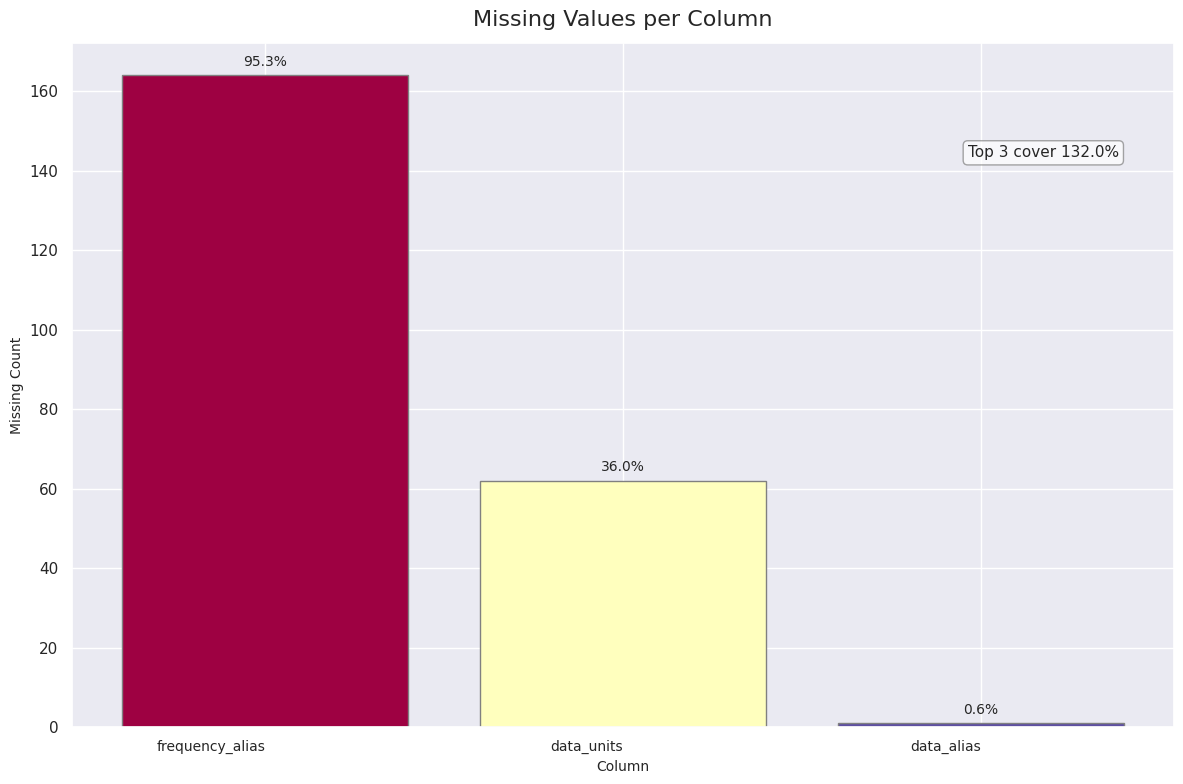

In [85]:
# Calculate missing counts and percentages.
missing_count = _get_missing_summary(df_metadata)
display(missing_count)
# Plot percentage of missing value.
caueduti.plot_top_n_annotated_bar(
    counts=missing_count["Missing Count"],
    total=len(df_metadata),
    top_n=len(missing_count),
    title="Missing Values per Column",
    xlabel="Column",
    ylabel="Missing Count",
    wrap_width=None,
    rotation=0,
)

Only three columns contain missing values: `frequency_alias`, `data_units`, and `data_alias`, with 95.3%, 36.0% and 0.6% missing values respectively. The missing `frequency_alias` and `data_alias` are not essential, as they serve only as display-friendly labels. While `data_units` is more relevant for interpreting values (e.g., whether a series is in MW or MWh), it is often redundant with dataset context and not required for structural analysis.

## Exploratory Analysis

### Distribution Analyses

#### Distribution by Dataset

The time series in the EIA electricity metadata originate from 19 distinct datasets, with the majority concentrated in a few categories. Notably, `electric_power_operational_data` and `summary` together account for nearly half of all parameter entries, suggesting they are the most comprehensive or widely used sources. In contrast, many other datasets contribute only a small number of entries, suggesting they are more specialized or narrowly scoped. This skewed distribution highlights key datasets likely to dominate downstream analysis.

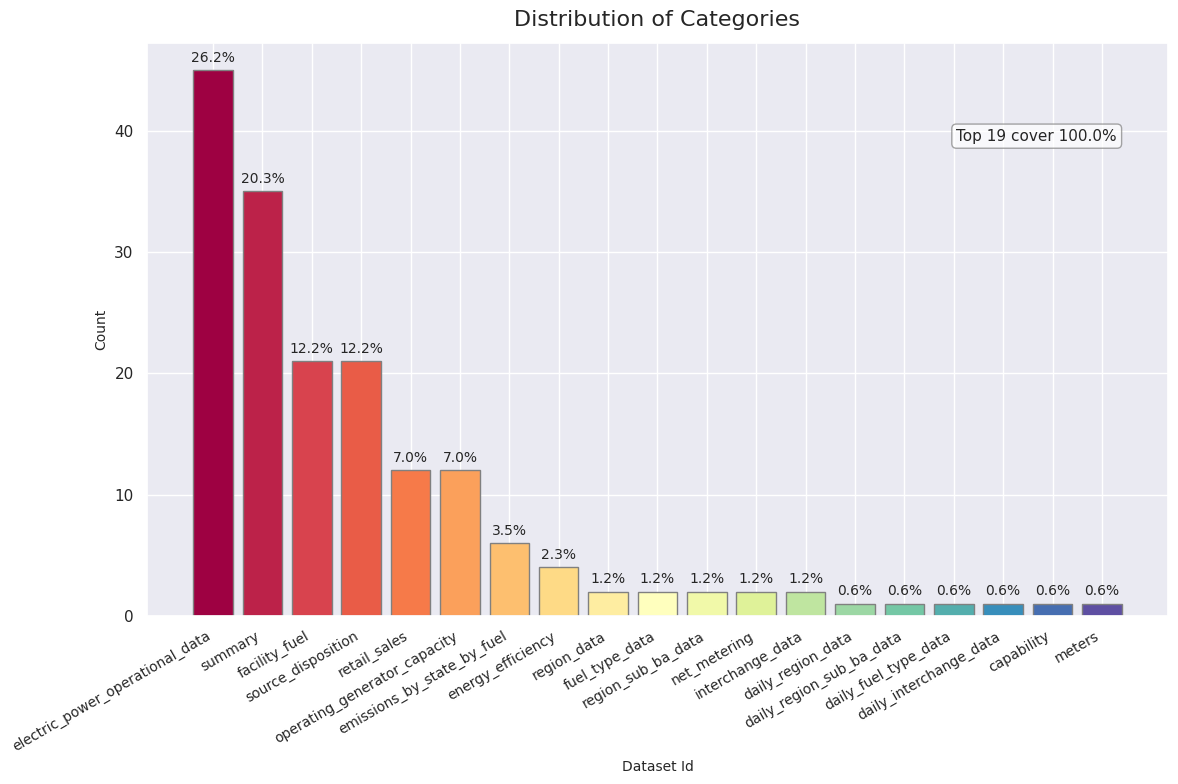

In [89]:
_plot_distribution(df_metadata, "dataset_id", "Distribution of Categories")

#### Distribution by Frequency

The dataset predominantly consists of annual (55.8%), monthly (22.1%), and quarterly (15.1%) time series, which together account for over 93% of the metadata. High-frequency data such as hourly and daily are rare, indicating the EIA primarily publishes coarse-grained electricity statistics rather than fine-grained real-time series.

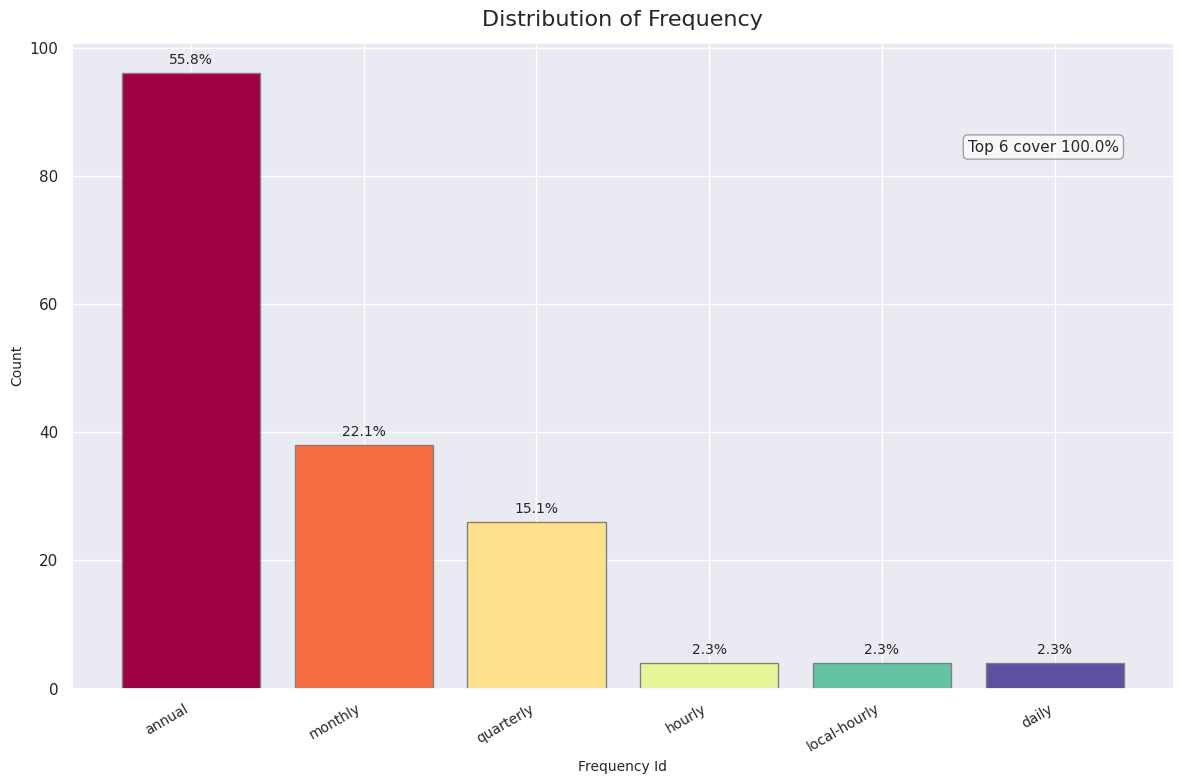

In [90]:
plot_distribution(df_metadata, "frequency_id", "Distribution of Frequency")

#### Distribution by Unit

The EIA electricity metadata is dominated by energy-related units, with `megawatthours` alone accounting for 26.7% of all time series. The top 16 units cover 64% of the data, indicating a moderate concentration across physical, economic, and environmental metrics. This suggests the dataset primarily captures electricity usage and generation, but also includes financial and emissions indicators. Analysts should be mindful of unit differences when comparing or aggregating series.

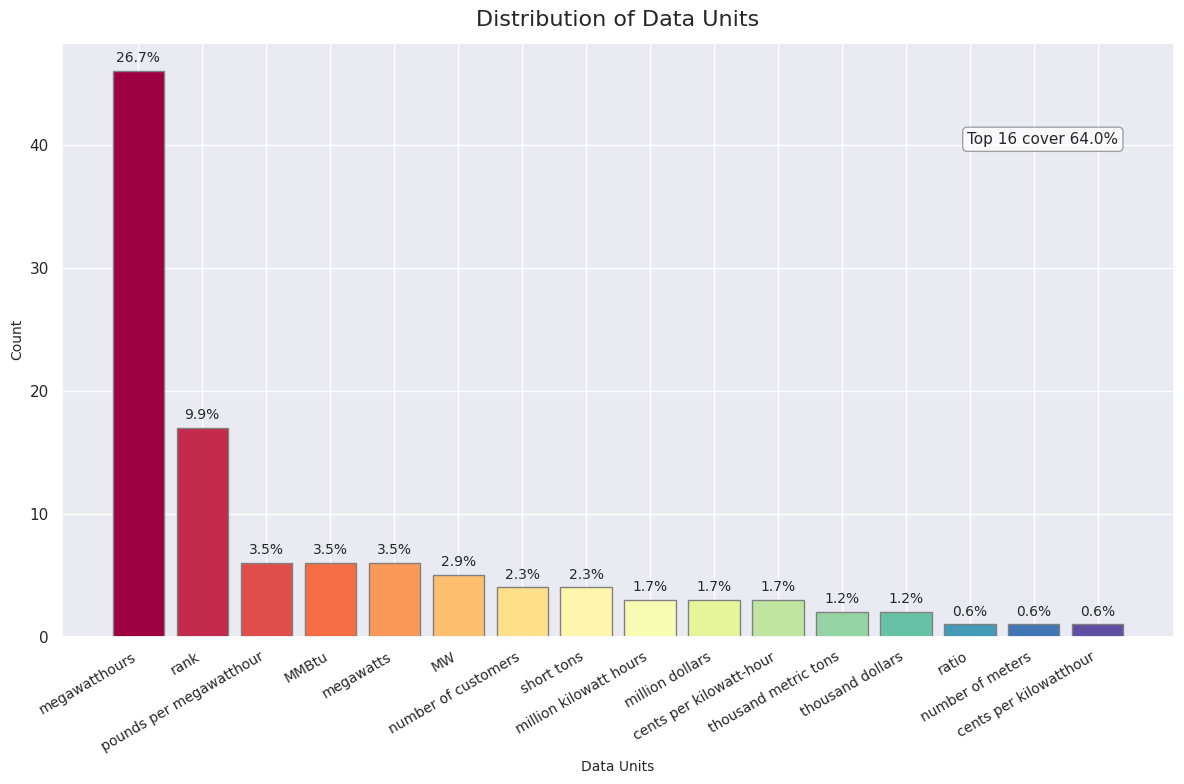

In [44]:
_plot_distribution(df_metadata, "data_units", "Distribution of Data Units")

### Coverage Analysis

#### Distribution by Timespan (Years)

Most time series in the dataset span around 25 years, indicating strong long-term data coverage. There are smaller peaks at approximately 15 and 33 years, suggesting that some datasets began earlier or were added more recently. Very few time series have less than 10 years of data, making this collection well-suited for historical trend analysis. The consistency in duration enhances its utility for longitudinal studies and forecasting tasks.

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'Distribution of Timespan (Years)'}, xlabel='Years of Coverage', ylabel='Count'>)

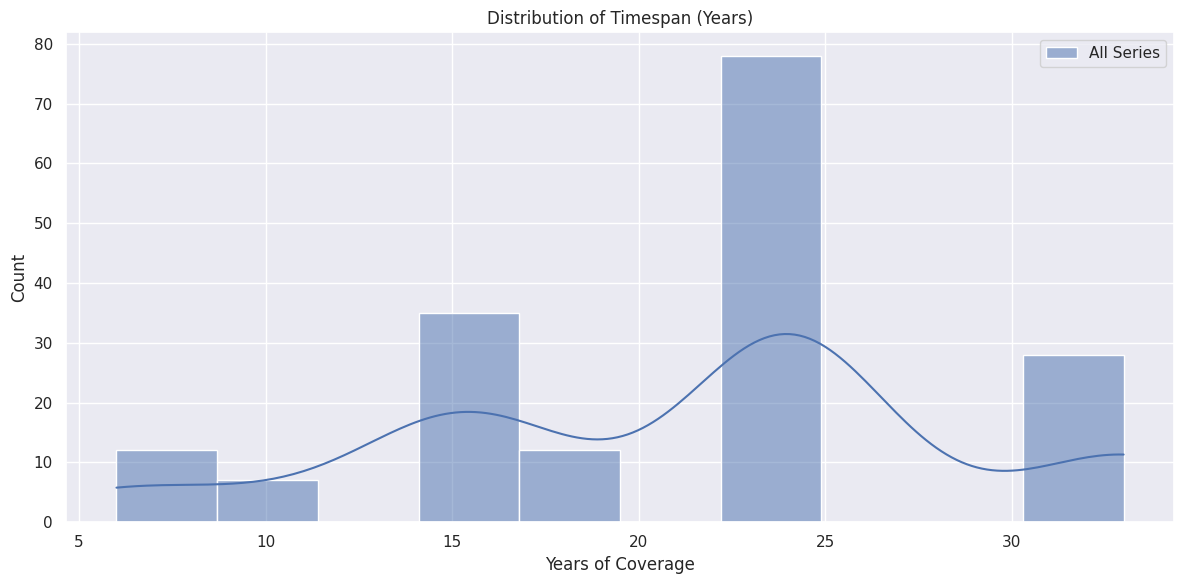

In [105]:
# Compute time span.
df_metadata["start_period_year"] = df_metadata["start_period"].str.extract(r"(\d{4})").astype(float)
df_metadata["end_period_year"] = df_metadata["end_period"].str.extract(r"(\d{4})").astype(float)
df_metadata["timespan_years"] = df_metadata["end_period_year"] - df_metadata["start_period_year"]
# Plot histogram of time spans.
caueduti.plot_histograms(
    data_series=[df_metadata["timespan_years"]],
    labels=["All Series"],
    colors=["C0"],
    bins=10,
    xlabel="Years of Coverage",
    title="Distribution of Timespan (Years)",
    figsize=(12, 6)
)

#### Distribution by Time Series Start Period

The distribution shows that most time series began around 2000–2001, suggesting a major expansion or standardization effort during that period. A smaller spike appears in 2008, possibly tied to policy or market shifts. After 2010, new series became increasingly rare, indicating a stabilization in data collection. Very few series started before 1995, likely due to limited historical digitization.

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'Distribution of Time Series Start Year'}, xlabel='Year', ylabel='Count'>)

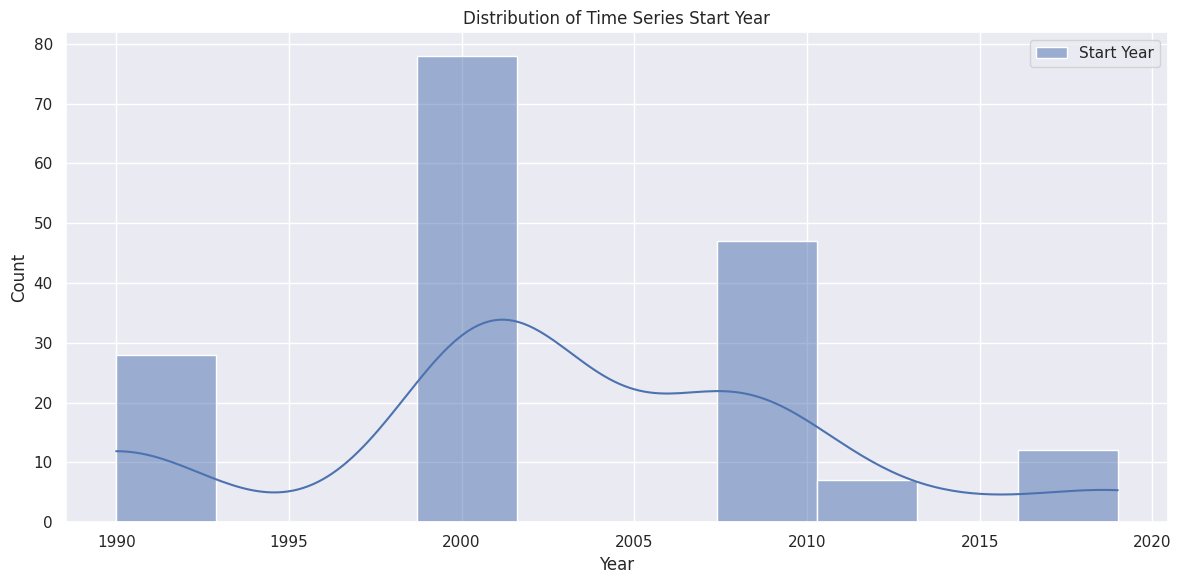

In [111]:
caueduti.plot_histograms(
    data_series=[df_metadata["start_period_year"]],
    labels=["Start Year"],
    colors=["C0"],
    bins=10,
    kde=True,
    xlabel="Year",
    title="Distribution of Time Series Start Year",
    figsize=(12, 6)
)

#### Distribution by Time Series End Period

The distribution of time series end years is highly concentrated in just two years: 2023 and 2025. This sharp clustering suggests that these values are likely system-generated or administrative placeholders rather than natural discontinuation points. Unlike the more varied start year distribution, the end year pattern indicates a bulk update or scheduled metadata cutoff. This means that not all of the series are necessarily discontinued, as 2023 may still be too recent to make that assumption.

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'Distribution of Time Series Start Year'}, xlabel='Year', ylabel='Count'>)

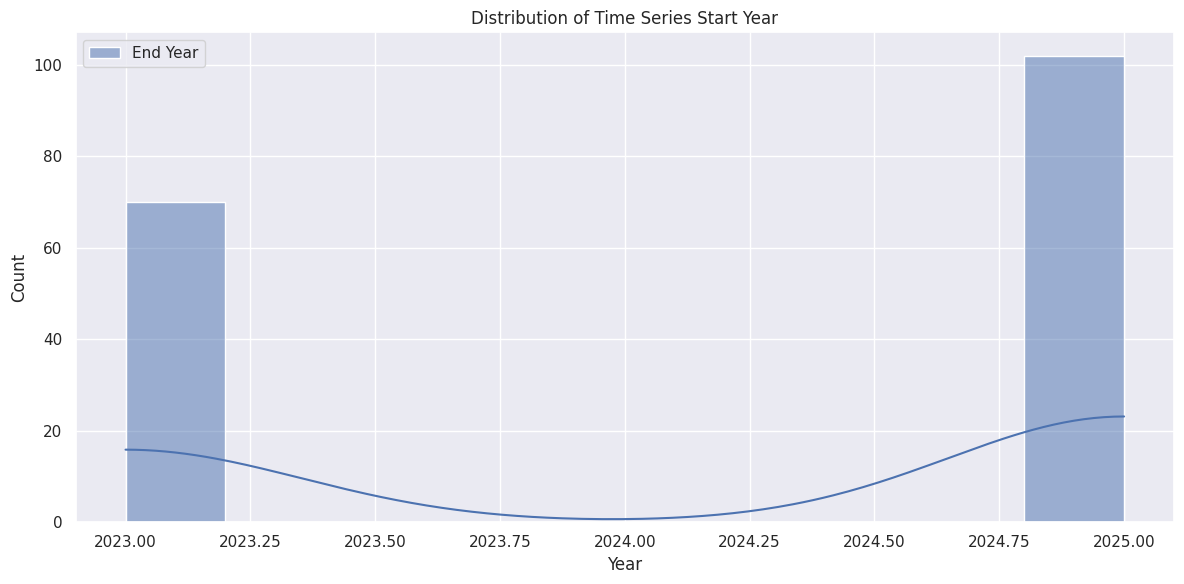

In [115]:
caueduti.plot_histograms(
    data_series=[df_metadata["end_period_year"]],
    labels=["End Year"],
    colors=["C0"],
    bins=10,
    kde=True,
    xlabel="Year",
    title="Distribution of Time Series Start Year",
    figsize=(12, 6)
)